# How has London's IPO market changed since 2005? LSE IPOs, 2005 to 2025

## Why I did this
I am interested in personal investing, and in the UK stock market in particular. Before looking at individual shares, I wanted to understand
the supply of new UK-listed companies: how many list, on which market, in which industries, how big they are and how much they raise. That tells
me what a private investor can realistically find among new listings, and how much of it is small, concentrated or cyclical. It also shows which
industries have been bringing companies to market at different points in the cycle, which is a way to learn about industries.

This is background, not a stock-picking signal. The data has no share prices, returns, valuations or trading volumes, so it says nothing about
how the companies performed after they listed. Nothing here is investment advice.

**What this can and cannot show.** It describes IPOs in London only. It cannot show whether London is a leading European listing venue, because that
needs IPO data from other exchanges and this dataset has none. The *Financials & Real Estate* group combines banks, insurers, property companies and
investment funds, so its share of IPOs is not a clean measure of financial services.

## Why 2005 to 2025

2005 to 2025 is a starting point: a 21-year window that covers the pre-crisis boom (2005 to 2007), the financial crisis, the 2010s, the pandemic and the recent slump. 2025 is the last complete year (2026 is excluded because the year is incomplete).

The source file starts in June 1995. 1995 to 2004 is excluded, not unavailable. From 2005 the issue types and industry groups are validated: LSEG uses 13 raw issue types across the whole file (11 from 2005), each maps to exactly one category from 2005 (checked by `load_db.py`), and every listing has an industry group. The earlier years have not been validated in the same way yet, and 437 listings from 1995 to 2004 carry 29 older sector names that are not mapped to an industry group (`CHECK - unmapped`). Extending the window back to 1995 is the first item of future work.

## Population: 2,282 IPOs
Rows with `year >= 2005`, LSEG's own flag `lse_ipo = 'IPO'`, `new_issues_type = 'New admission'`, on the UK Main Market, the International Main Market
or AIM.
- **What counts as an IPO.** LSEG's `IPO` flag, which excludes reverse takeovers, introductions and transfers between markets. The
  harmonised `New admission` category includes 2,133 new company placings, 135 international GDR offerings and 14 offers for subscription.
- **Why three markets.** The Specialist Fund Market (SFM) and Professional Securities Market (PSM) are specialist segments rather than the
  Main Market and AIM. 20 of the 24 SFM listings are in investment-fund sectors. Excluding both removes 38 of 2,320 rows (1.6%) and barely moves the
  results (AIM's share of 2005 to 2007 IPOs goes from 75% to 76%).

**AI assistance.** I used Claude (Anthropic's AI assistant) in this project. It assigned industry groups to the 107 listings that had no FTSE sector, working from sources I
specified (the company's website, its LSE page or Wikipedia), and I checked each one. It helped map the 95 FTSE sector labels to industry groups from my instruction
("match the sector labels to the 9 types"). I used it as a learning tool while writing `load_db.py`, my first data-validation script, and it helped revise the notebook and README text.
See the README for details.

**Inputs.** `lse.db`, built by `python3 load_db.py` from LSEG data that is **not included in this repository** (see the Data section of the README).
The saved outputs below were produced from that database, so the results can be read without re-running anything.

**Outputs.** Six figures in `figures/` and four tables in `results/`.

**Run order.** Kernel > Restart & Run All.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if not Path("lse.db").exists():
    raise FileNotFoundError("lse.db not found. Build it first with `python3 load_db.py` "
                            "(the LSEG data is not included; see the Data section of the README).")

FIGURES, RESULTS = Path("figures"), Path("results")
FIGURES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

# Categorical colours in a fixed order (a colour-blind-safe sequence for adjacent series); 'Other' is always grey.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
OTHER_GREY = "#8a8a85"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "axes.titlesize": 13, "axes.titleweight": "bold",
})

Load JupySQL (the `%sql` / `%%sql` magics) and connect to the database built by `load_db.py`.

In [2]:
%load_ext sql
%sql sqlite:///lse.db
%config SqlMagic.displaylimit = 25

Connecting to 'sqlite:///lse.db'

### Provenance check
`load_metadata` records the SHA-256 hash and row count of each source file the database was built from, so any result here
can be traced to an exact export.

In [3]:
%sql SELECT source_file, row_count, substr(sha256, 1, 12) AS sha256_start FROM load_metadata;

Running query in 'sqlite:///lse.db'

source_file,row_count,sha256_start
new_issues.csv,6251,d461860335fe
sector_map.csv,96,3596345c4a1d
manual_sector_review.csv,107,1c3fcef4f9a1


Confirm the IPO flag has only two values, so `lse_ipo = 'IPO'` cannot miss rows because of a spelling variant.

In [4]:
%sql SELECT lse_ipo, COUNT(*) AS n_rows FROM new_issues GROUP BY lse_ipo;

Running query in 'sqlite:///lse.db'

lse_ipo,n_rows
IPO,3766
Not IPO,2485


## 1. Build the analysis population

In [5]:
%%sql q1 <<
SELECT *
FROM new_issues
WHERE year >= 2005
  AND lse_ipo = 'IPO'
  AND new_issues_type = 'New admission'
  AND market IN ('UK Main Market', 'International Main Market', 'AIM')
ORDER BY date;

Running query in 'sqlite:///lse.db'

Convert to pandas and check the row count matches the loader's printout (2,282).

In [6]:
df = q1.DataFrame()
assert len(df) == 2282, f"expected 2,282 IPOs, got {len(df)}"
assert df["year"].between(2005, 2025).all()
print(f"{len(df):,} IPOs, {df['year'].min()} to {df['year'].max()}")

2,282 IPOs, 2005 to 2025


## 2. How many IPOs, and how much new money, per year?

`money_raised_new_m` is money raised by issuing **new** shares (£m). Proceeds from selling existing shares are not used:
`total_raised_m` is blank for most rows, so it would understate totals unpredictably.

In [7]:
%%sql per_year <<
SELECT
    year,
    COUNT(*)                                    AS ipos,
    ROUND(SUM(money_raised_new_m) / 1000.0, 2)  AS new_money_bn,
    SUM(market = 'AIM')                         AS aim_ipos
FROM new_issues
WHERE year >= 2005
  AND lse_ipo = 'IPO'
  AND new_issues_type = 'New admission'
  AND market IN ('UK Main Market', 'International Main Market', 'AIM')
GROUP BY year
ORDER BY year;

Running query in 'sqlite:///lse.db'

In [8]:
per_year = per_year.DataFrame().set_index("year")
assert per_year["ipos"].sum() == len(df)   # the SQL aggregate and the pandas population agree
per_year

,ipos,new_money_bn,aim_ipos
year,,,
2005,421,16.27,335
2006,363,28.83,278
2007,264,25.37,182
2008,70,6.97,38
2009,22,1.30,13
2010,92,9.33,47
2011,75,15.87,45
2012,65,4.75,43
2013,98,11.42,62


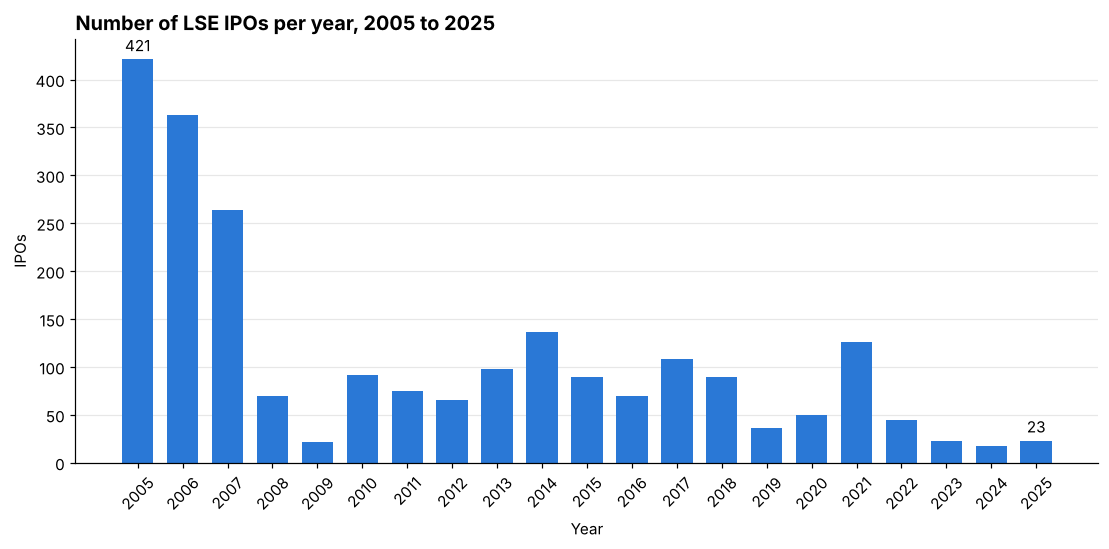

In [9]:
def bar_by_year(series, title, ylabel, filename, fmt="{:,.0f}"):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(series.index, series.values, color=PALETTE[0], width=0.7)
    peak = series.idxmax()
    for year in (peak, series.index.max()):   # label only the peak and the latest year
        ax.annotate(fmt.format(series[year]), (year, series[year]), ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points", fontsize=10)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(series.index)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="x", visible=False)
    fig.savefig(FIGURES / filename)
    plt.show()

bar_by_year(per_year["ipos"], "Number of LSE IPOs per year, 2005 to 2025", "IPOs", "q1_ipos_per_year.png")

**What it shows.** IPO volume collapsed and never recovered. 2005 was the peak (421 IPOs), and 2005 to 2007 alone account for
1,048 of the 2,282 IPOs (46%), an average of 349 a year. The 2010s averaged 86 a year (858 over ten years) and 2022 to 2025 averaged 27
(108 over four). 2021 (126) was a short spike. 2024 (17) is the lowest year in the series; only 2009 (22) comes close.

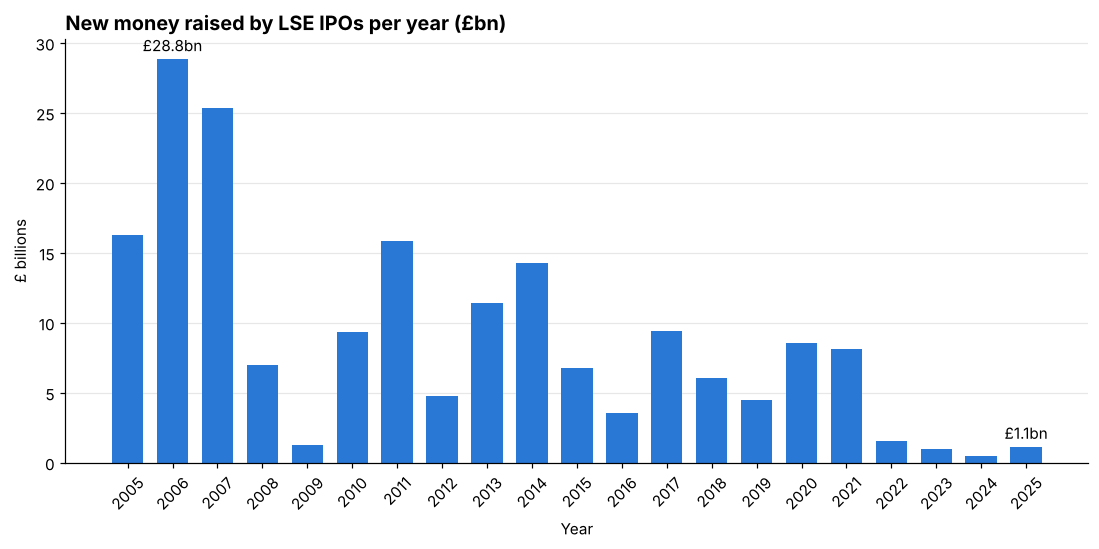

In [10]:
bar_by_year(per_year["new_money_bn"], "New money raised by LSE IPOs per year (£bn)", "£ billions",
            "q1_new_money_by_year.png", fmt="£{:.1f}bn")

**What it shows.** New money peaked at £28.8bn in 2006. The four years 2022 to 2025 together raised £4.2bn, less than any single year
from 2005 to 2007 and about a seventh of 2006 alone. Single large listings drive the spikes: 2011's £15.9bn includes Glencore's £6.2bn.

## 3. Size of the typical IPO

Totals are dominated by a handful of very large listings (Glencore raised £6.2bn in 2011), so the **median** new money per IPO
describes the typical listing better than the mean. SQLite has no median function, so this step uses pandas.

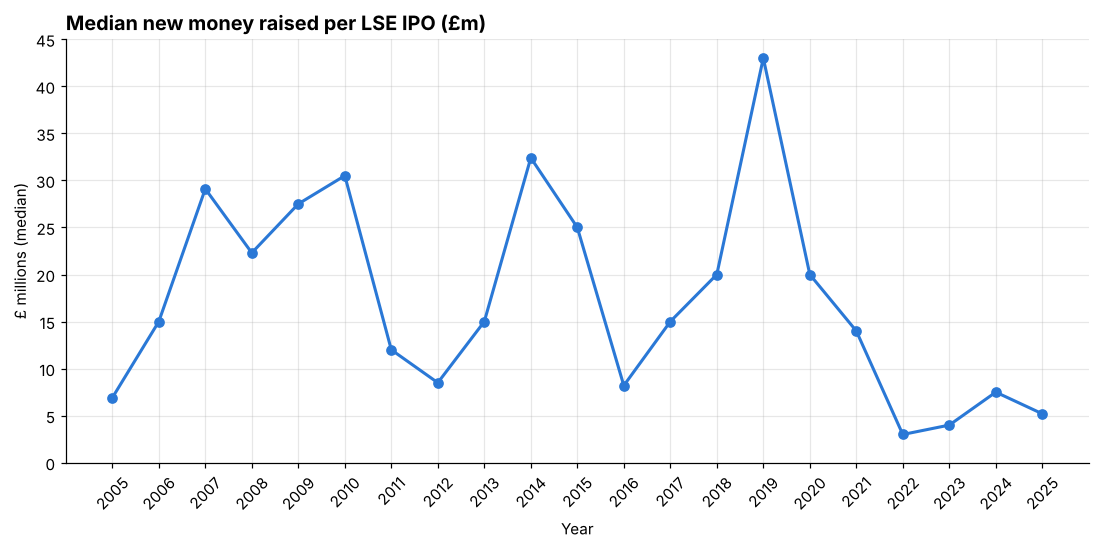

,ipos,median_raise_m,mean_raise_m,median_market_cap_m
year,,,,
2005,421,6.9,38.6,20.1
2006,363,15.0,79.4,38.0
2007,264,29.1,96.1,58.9
2008,70,22.3,99.5,43.0
2009,22,27.5,59.2,24.3
2010,92,30.5,101.4,49.7
2011,75,12.0,211.6,21.4
2012,65,8.5,73.1,31.7
2013,98,15.0,116.5,58.9


In [11]:
size = df.groupby("year").agg(
    ipos=("company", "size"),
    median_raise_m=("money_raised_new_m", "median"),
    mean_raise_m=("money_raised_new_m", "mean"),
    median_market_cap_m=("market_cap_opening_price_m", "median"),
).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(size.index, size["median_raise_m"], color=PALETTE[0], linewidth=2, marker="o", markersize=6)
ax.set_title("Median new money raised per LSE IPO (£m)", loc="left")
ax.set_xlabel("Year")
ax.set_ylabel("£ millions (median)")
ax.set_xticks(size.index)
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=0)
fig.savefig(FIGURES / "q1_median_raise.png")
plt.show()
size

**What it shows.** The typical IPO has shrunk sharply. The median raise was between £11m and £24m in every period before 2022
(£11.2m in 2005 to 2007, £23.8m in 2008 to 2009, £15.0m in 2010 to 2019 and in 2020 to 2021), then fell to £4.3m in 2022 to 2025. Every year
since 2022 is below £8m. The mean is several times the median in most years (2011: £211.6m mean against £12.0m median), which confirms that
totals are driven by a few very large listings.
*Caution:* yearly medians in low-volume years rest on few IPOs (2009: 22, 2024: 17).

## 4. Which market and which industries?

**Method.** For each year, share (%) = IPOs in a category ÷ all IPOs that year × 100. Shares in low-volume years rest on few
listings (see the IPO count chart), so a single listing moves them by several points.

Industry is the `ftse_group` column: each FTSE sector label in the data was mapped to one of nine broad industry groups (see `sector_map.csv`),
plus a small *Non-company security* category. To keep the chart readable, groups outside the seven largest are folded into *Other*.

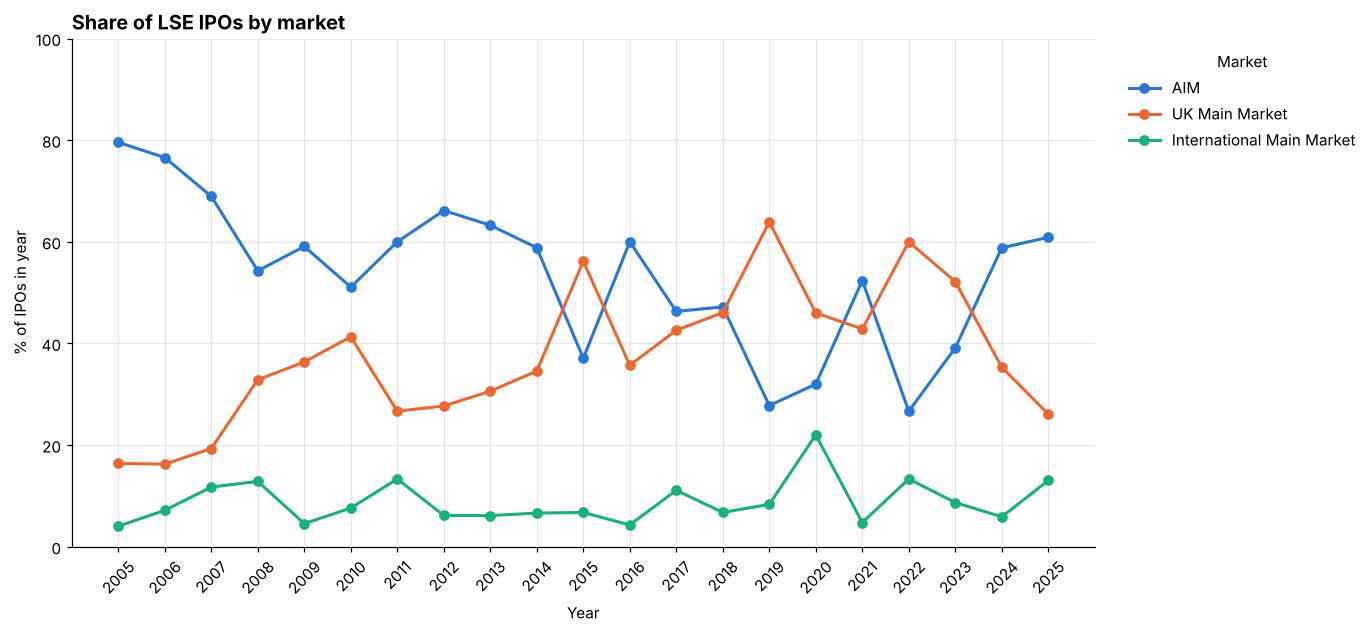

In [12]:
def share_by_year(df, col, top_n=None):
    """% of each year's IPOs falling in each category of `col`."""
    d = df.dropna(subset=["year", col]).copy()
    if top_n:  # keep the biggest categories, lump the rest into 'Other'
        top = d[col].value_counts().nlargest(top_n).index
        d[col] = d[col].where(d[col].isin(top), "Other")
    counts = d.groupby(["year", col]).size().unstack(fill_value=0)
    order = counts.sum().sort_values(ascending=False).index.tolist()
    if "Other" in order:   # 'Other' always last
        order.remove("Other"); order.append("Other")
    counts = counts[order]
    return counts.div(counts.sum(axis=1), axis=0) * 100   # (n in group / total IPOs that year) * 100

def plot_share(pct, title, ylabel, filename, area=False):
    fig, ax = plt.subplots(figsize=(12, 6))
    colours = [OTHER_GREY if name == "Other" else PALETTE[i] for i, name in enumerate(pct.columns)]
    if area:  # shares sum to 100%, so a stacked area shows the mix per year
        ax.stackplot(pct.index, pct.T.values, labels=pct.columns, colors=colours,
                     edgecolor="white", linewidth=0.8, alpha=0.9)
        ax.set_xlim(pct.index.min(), pct.index.max())
    else:
        for column, colour in zip(pct.columns, colours):
            ax.plot(pct.index, pct[column], label=column, color=colour, linewidth=2, marker="o", markersize=6)
    ax.set_ylim(0, 100)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(pct.index)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title=pct.columns.name, frameon=False)
    fig.savefig(FIGURES / filename)
    plt.show()

market_pct = share_by_year(df, "market")
market_pct.columns.name = "Market"
plot_share(market_pct, "Share of LSE IPOs by market", "% of IPOs in year", "q1_market_share.png")

**What it shows.** AIM's dominance faded. AIM took about 80% of IPOs in 2005 and 76% across 2005 to 2007, but only 42% across
2022 to 2025, while the UK Main Market rose from 17% to 47%. The International Main Market stays between 7% and 11% of IPOs in every period.
*Caution:* AIM's share is back near 60% in 2024 and 2025, but on only 17 and 23 IPOs, which is too few listings to call a reversal.

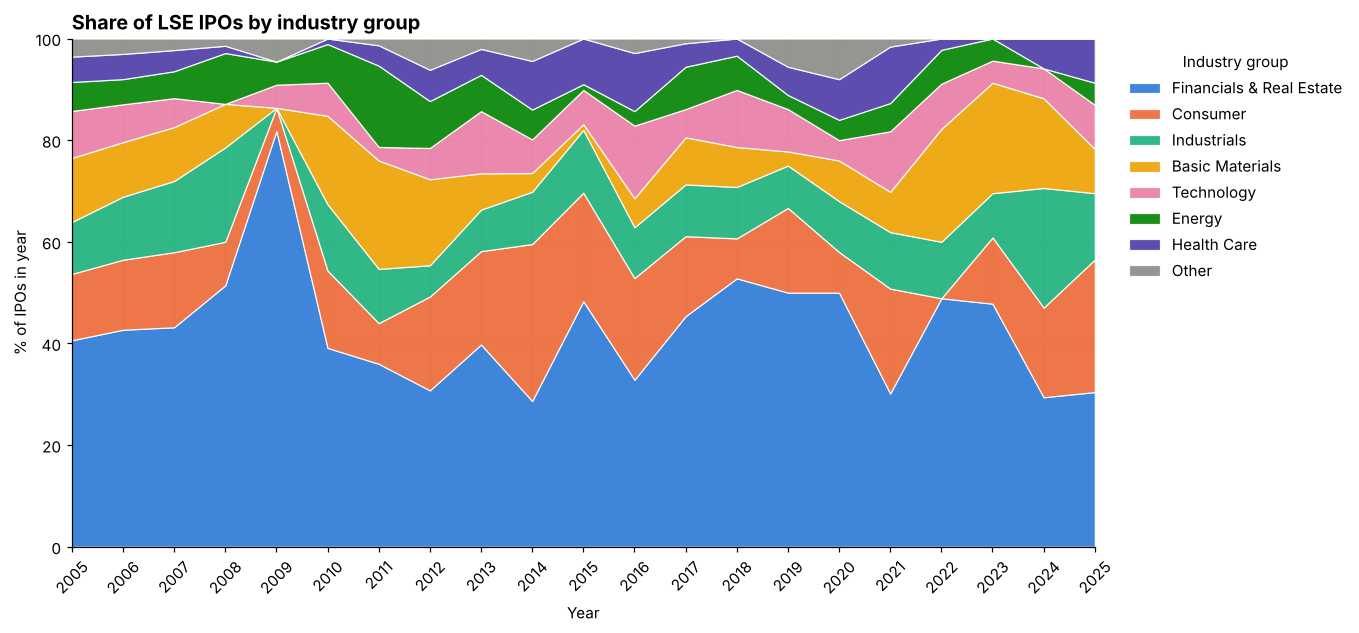

In [13]:
industry_pct = share_by_year(df, "ftse_group", top_n=7)
industry_pct.columns.name = "Industry group"
plot_share(industry_pct, "Share of LSE IPOs by industry group", "% of IPOs in year",
           "q1_industry_share.png", area=True)

**What it shows.** Financials & Real Estate is the largest group in every period (42.0% of IPOs in 2005 to 2007, 58.7% in 2008 to 2009,
39.7% in 2010 to 2019, 35.8% in 2020 to 2021 and 41.7% in 2022 to 2025). The industry mix is therefore not what changed most: the share
in 2022 to 2025 is almost the same as in 2005 to 2007. What changed is the volume behind it (see the conclusions). Basic Materials
rose to 18.5% in 2022 to 2025 (from 11.5% in 2005 to 2007; 12 of its 20 IPOs in 2022 to 2025 are mining by sector name and 7 are blank-sector
listings in `manual_sector_review.csv`), and Health Care peaked at 10.2% in 2020 to 2021.

*Caution:* the Financials & Real Estate group combines banks, insurers, property companies and investment funds, so its share is not a
clean measure of financial services. Shares in low-volume years are also volatile: the 82% in 2009 rests on 22 IPOs.

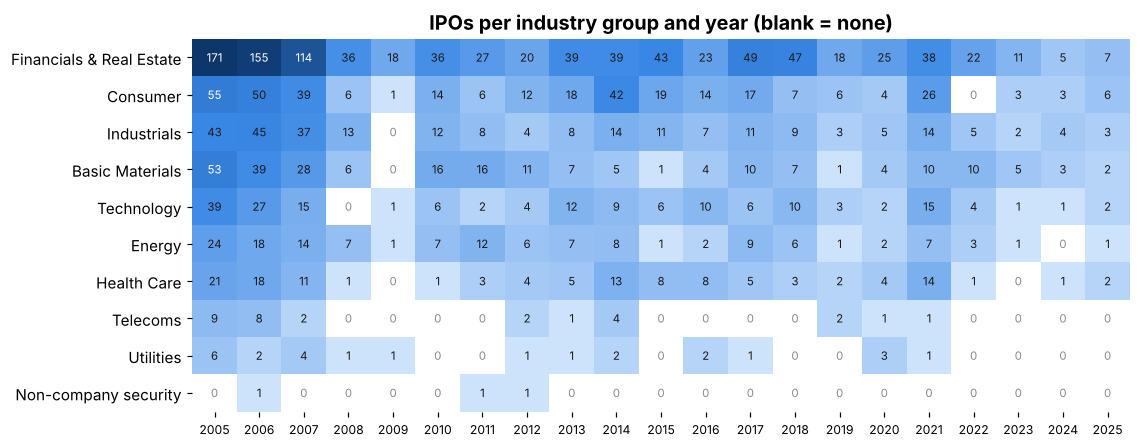

In [14]:
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

group_by_year = pd.crosstab(df["ftse_group"], df["year"]).reindex(columns=range(2005, 2026), fill_value=0)
group_by_year = group_by_year.loc[group_by_year.sum(axis=1).sort_values(ascending=False).index]
group_by_year.to_csv(RESULTS / "group_by_year.csv")

values = group_by_year.to_numpy()
cmap = LinearSegmentedColormap.from_list("blue_ramp", ["#cde2fb", "#3987e5", "#0d366b"]).with_extremes(bad="white")
norm = PowerNorm(gamma=0.5, vmin=1, vmax=values.max())   # square-root scale so small groups stay visible next to Financials
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.imshow(np.ma.masked_equal(values, 0), cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(values.shape[1]), group_by_year.columns, fontsize=8)
ax.set_yticks(range(values.shape[0]), group_by_year.index)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
for row in range(values.shape[0]):
    for col in range(values.shape[1]):
        n = values[row, col]
        dark_cell = n > 0 and norm(n) > 0.55
        ax.text(col, row, str(n), ha="center", va="center", fontsize=7.5,
                color="white" if dark_cell else ("#8a8a85" if n == 0 else "#1a1a1a"))
ax.set_title("IPOs per industry group and year (blank = none)")
fig.savefig(FIGURES / "q1_industry_heatmap.png")
plt.show()

**Coverage check.** The heatmap checks that the industry grouping is populated in every period. The seven largest groups have IPOs in almost every year; the only gaps are 2009
(Basic Materials, Health Care, Industrials), 2008 (Technology), 2022 (Consumer), 2023 (Health Care) and 2024 (Energy). Telecoms has no IPOs in 12 of the 21 years and Utilities in 9
(neither has any in 2022 to 2025), and Non-company security has only three IPOs in total, so shares for those groups rest on very few listings. This shows the groups are populated,
not that each sector label sits in the right group. The counts are saved to `results/group_by_year.csv`.

## 5. Summary by period

Periods follow the market cycle: pre-crisis boom (2005 to 2007), financial crisis (2008 to 2009), recovery (2010 to 2019),
pandemic boom (2020 to 2021) and the recent slump (2022 to 2025). The table is saved to `results/summary_by_period.csv`.

Size columns use `market_cap_opening_price_m` (market value at the opening price, £m), which is blank for 43 of the 2,282 IPOs; percentages and
medians use the rows that have a value. `fund_sectors_pct` is the share of IPOs whose FTSE sector is a fund or investment-vehicle sector
(`Equity Investment Instruments`, `Nonequity Investment Instruments`, `Open End and Miscellaneous Investment Vehicles`, `Closed End Investments`). It uses the sector
names LSEG supplies, both before and after the 2019 reclassification, so no judgement of mine is involved. The `_ex_funds` columns repeat the medians without those sectors.

In [15]:
FUND_SECTORS = ["Equity Investment Instruments", "Nonequity Investment Instruments",
                "Open End and Miscellaneous Investment Vehicles", "Closed End Investments"]
is_fund = df["ftse_sector"].isin(FUND_SECTORS)
periods = pd.cut(df["year"], bins=[2004, 2007, 2009, 2019, 2021, 2025],
                 labels=["2005-07", "2008-09", "2010-19", "2020-21", "2022-25"])
share_under_50m = lambda s: 100 * (s < 50).sum() / s.notna().sum()
ex_funds = df[~is_fund].groupby(periods[~is_fund], observed=True)

summary = pd.concat([
    df.groupby(periods, observed=True).agg(
        ipos=("company", "size"),
        new_money_bn=("money_raised_new_m", lambda s: s.sum() / 1000),
        median_raise_m=("money_raised_new_m", "median"),
        median_market_cap_m=("market_cap_opening_price_m", "median"),
        cap_under_50m_pct=("market_cap_opening_price_m", share_under_50m),
    ),
    (is_fund.groupby(periods, observed=True).mean() * 100).rename("fund_sectors_pct"),
    ex_funds["money_raised_new_m"].median().rename("median_raise_ex_funds_m"),
    ex_funds["market_cap_opening_price_m"].median().rename("median_market_cap_ex_funds_m"),
    pd.crosstab(periods, df["market"], normalize="index").mul(100).add_suffix(" %"),
    pd.crosstab(periods, df["ftse_group"], normalize="index").mul(100).add_suffix(" %"),
], axis=1).round(1)
summary.index.name = "period"
summary.to_csv(RESULTS / "summary_by_period.csv")
summary.T

period,2005-07,2008-09,2010-19,2020-21,2022-25
ipos,1048.0,92.0,858.0,176.0,108.0
new_money_bn,70.5,8.3,85.9,16.6,4.2
median_raise_m,11.2,23.8,15.0,15.0,4.3
median_market_cap_m,31.5,39.4,66.8,89.1,20.3
cap_under_50m_pct,60.7,56.7,44.5,38.6,78.5
fund_sectors_pct,9.8,39.1,22.7,14.8,21.3
median_raise_ex_funds_m,10.0,11.7,13.6,16.0,5.0
median_market_cap_ex_funds_m,30.8,42.4,76.7,94.1,21.4
AIM %,75.9,55.4,52.9,46.6,41.7
International Main Market %,7.1,10.9,7.7,9.7,11.1


The table above holds every period figure quoted in the README.

### Baseline check: compared with *which* past?
The periods above start at 2005, the busiest years in the data. Comparing the recent slump only with 2005 to 2007 would overstate the fall.
This cell compares 2022 to 2025 with four baselines: the 2005 to 2007 boom, 2008 to 2012 (financial crisis and recovery), a wider 2007 to 2013, and the 2010s.
I set these baselines after seeing the first results, so the table shows all four and the conclusion does not depend on my choice.
Per-year averages are used because the windows have different lengths.

In [16]:
def window_stats(df, start, end):
    w = df[df["year"].between(start, end)]
    years = end - start + 1
    return {"ipos_per_year": len(w) / years,
            "new_money_bn_per_year": w["money_raised_new_m"].sum() / 1000 / years,
            "median_raise_m": w["money_raised_new_m"].median()}

baselines = {
    "2005-07 (pre-crisis boom)":           (2005, 2007),
    "2008-12 (crisis and recovery)":       (2008, 2012),
    "2007-13 (wider reading)":             (2007, 2013),
    "2010-19 (the 2010s)":                 (2010, 2019),
}
recent = window_stats(df, 2022, 2025)
rows = []
for label, (start, end) in baselines.items():
    base = window_stats(df, start, end)
    rows.append({"baseline": label, **{k: round(v, 1) for k, v in base.items()},
                 **{f"2022-25 as % of baseline: {k}": round(100 * recent[k] / base[k]) for k in base}})
baseline_check = pd.DataFrame(rows).set_index("baseline")

Path("results").mkdir(exist_ok=True)
baseline_check.to_csv("results/baseline_check.csv")
print("2022-25:", {k: round(float(v), 1) for k, v in recent.items()})
baseline_check

2022-25: {'ipos_per_year': 27.0, 'new_money_bn_per_year': 1.0, 'median_raise_m': 4.3}


,ipos_per_year,new_money_bn_per_year,median_raise_m,2022-25 as % of baseline: ipos_per_year,2022-25 as % of baseline: new_money_bn_per_year,2022-25 as % of baseline: median_raise_m
baseline,,,,,,
2005-07 (pre-crisis boom),349.3,23.5,11.2,8,4,39
2008-12 (crisis and recovery),64.8,7.6,14.4,42,14,30
2007-13 (wider reading),98.0,10.7,20.0,28,10,22
2010-19 (the 2010s),85.8,8.6,15.0,31,12,29


**What it shows.** Whichever baseline is used, today's IPO market is far smaller. The 2022 to 2025 IPO rate is **42%** of the 2008 to 2012 rate
(27 against 65 a year), 28% of 2007 to 2013, 31% of the 2010s and 8% of the 2005 to 2007 boom. New money raised per year is between 4% and 14%
of every baseline. The choice of baseline changes the *size* of the fall, not its direction. Using 2005 to 2007 alone would overstate it.

## 6. What this means for a UK personal investor

These are observations about the supply of new UK listings, not recommendations and not investment advice. The data has no share prices, returns,
valuations or trading volumes, so it cannot say whether any listing was a good investment or how easy it was to trade. The cell below computes the
extra figures used here (the rest are in the summary table above).

In [17]:
def size_table(d):
    return d.groupby("market").agg(ipos=("company", "size"), median_market_cap_m=("market_cap_opening_price_m", "median"))

size_by_market = pd.concat({"2005-25": size_table(df), "2022-25": size_table(df[df["year"] >= 2022])}, axis=1).round(1)
size_by_market.to_csv(RESULTS / "size_by_market.csv")
display(size_by_market)

recent_ipos = df[df["year"] >= 2022]
groups = recent_ipos["ftse_group"].value_counts()
top3 = groups.head(3)
print(f"Industry groups, 2022-25 ({len(recent_ipos)} IPOs):\n{groups.to_string()}")
print(f"Top three ({', '.join(top3.index)}): {top3.sum()} of {len(recent_ipos)} = {top3.sum() / len(recent_ipos):.1%}")
print(f"Of the {groups['Financials & Real Estate']} Financials & Real Estate IPOs, {int(is_fund[recent_ipos.index][recent_ipos['ftse_group'] == 'Financials & Real Estate'].sum())} are in fund or investment-vehicle sectors")
print("\nIPOs per year:", df.groupby("year").size().to_dict())

2005-25                     2022-25  \
                             ipos median_market_cap_m    ipos   
market                                                          
AIM                          1427                29.2      45   
International Main Market     179               300.6      12   
UK Main Market                676               100.0      51   

                                               
                          median_market_cap_m  
market                                         
AIM                                      26.0  
International Main Market               112.2  
UK Main Market                            5.0

Industry groups, 2022-25 (108 IPOs):
ftse_group
Financials & Real Estate    45
Basic Materials             20
Industrials                 14
Consumer                    12
Technology                   8
Energy                       5
Health Care                  4
Top three (Financials & Real Estate, Basic Materials, Industrials): 79 of 108 = 73.1%
Of the 45 Financials & Real Estate IPOs, 23 are in fund or investment-vehicle sectors

IPOs per year: {2005: 421, 2006: 363, 2007: 264, 2008: 70, 2009: 22, 2010: 92, 2011: 75, 2012: 65, 2013: 98, 2014: 136, 2015: 89, 2016: 70, 2017: 108, 2018: 89, 2019: 36, 2020: 50, 2021: 126, 2022: 45, 2023: 23, 2024: 17, 2025: 23}


**1. New listings are a thin source of ideas.** There were 23, 17 and 23 IPOs in 2023, 2024 and 2025, about two a month, against an average of 349 a year in
2005 to 2007. Anyone using new listings as a source of ideas now has very few to look at.

**2. They are small, and smaller than before.** The median opening market value was £20.3m in 2022 to 2025, against £66.8m in the 2010s, and 78.5% of 2022 to 2025 IPOs opened below £50m
(44.5% in the 2010s). Over 2005 to 2025 the median was £29.2m on AIM, £100.0m on the UK Main Market and £300.6m on the International Main Market. This is not just shell companies and funds: without the
fund and investment-vehicle sectors the 2022 to 2025 median is £21.4m and 79.5% are below £50m. Recent Main Market listings are especially small: the 2022 to 2025 median there is £5.0m (51 IPOs), and 17 of those 51 are in fund or investment-vehicle sectors (without them, £8.5m). AIM is a market for smaller, growing companies with more flexible regulatory requirements than the Main Market
([nibusinessinfo](https://www.nibusinessinfo.co.uk/content/what-aim)). Very small companies are generally harder to buy and sell and have less public information, but this data has no trading volumes, so it
cannot measure that.

**3. Recent listings are concentrated in a few industries, and are not a map of the UK economy.** In 2022 to 2025, Financials & Real Estate (45), Basic Materials (20) and Industrials (14) made up 79 of 108 IPOs (73.1%),
and Technology (8) and Health Care (4) made up 12. Of the 45 Financials & Real Estate IPOs, 23 are in fund or investment-vehicle sectors. Using new listings to learn about industries therefore gives a skewed picture:
it shows what is coming to market, not what makes up the wider UK market, which this data does not cover.

**4. Volume swings a lot, so a busy year is not the normal year.** There were 421 IPOs in 2005, 22 in 2009, 126 in 2021 and 17 in 2024. The two boom years came before the 2008 to 2009 crash and the 2022 to 2025 slump, but that is two
cycles, so it is not evidence that IPO waves predict anything, and the data has no returns to test it with.

**5. Questions to ask about any new UK listing, which this analysis points to:** Which market is it on? How big is it at the opening price compared with the figures above? Is it an operating business or a fund or shell (check
the FTSE sector)? How much did it raise? None of these says whether it is a good investment.

## Conclusions

1. **Not in volume.** 2,282 IPOs from 2005 to 2025, 46% of them in 2005 to 2007 (349 a year, against 86 a year in the 2010s and 27 a year in 2022 to 2025).
   2024 (17) is the lowest year in the series.
2. **The typical IPO is much smaller.** The median new money per IPO fell from between £11m and £24m in every period before 2022 to £4.3m in 2022 to 2025,
   and total new money in 2022 to 2025 (£4.2bn) was about a seventh of 2006 alone. Median opening market value fell from £66.8m in the 2010s to £20.3m, and the result holds without fund and investment-vehicle sectors.
3. **AIM lost its dominance to the Main Market.** AIM's share fell from 76% (2005 to 2007) to 42% (2022 to 2025); the UK Main Market's rose from 17% to 47%.
4. **The industry mix held; the volume did not.** Financials & Real Estate was 42% of IPOs in both 2005 to 2007 and 2022 to 2025, but that is about 147 IPOs
   a year then (440 in total) and about 11 a year now (45 in total). The group mixes banks, insurers, property and investment funds, so this is not a clean
   measure of financial services.
5. **The baseline matters, but not the conclusion.** The high-water mark in this data is 2005 to 2007. Against 2008 to 2012 (65 IPOs and £7.6bn of new money a year),
   2022 to 2025 runs at 42% of the IPO rate and 14% of the new money; against any other baseline the fall is larger or similar (see the baseline check in section 5).
6. **For a UK personal investor** (section 6): new listings are few, small, concentrated in a handful of industries and highly cyclical. That makes them a limited
   and uneven source of ideas, and this data cannot say whether they were good investments.

**What this does not show.** Whether London is a leading European listing venue (there is no data from other exchanges), or how listed companies performed (there are no returns).

### Limitations
- **Descriptive only.** This shows *what* changed, not *why* (valuations, interest rates, regulation and listing rules all moved in this period).
- **New money only.** Money from selling existing shares is not reliably recorded, so totals understate what IPOs raised. Some listings raised nothing new, which pulls medians down.
- **Small recent samples.** 2022 to 2025 contains 108 IPOs; single listings move yearly shares and medians a lot.
- **Industry groups are a judgement.** Each FTSE sector label was mapped to a broad group based on its name (`sector_map.csv`), and 107 blank-sector listings were assigned a group by Claude from sources I specified and I checked (`manual_sector_review.csv`).
  FTSE sector names changed over the period (legacy names, then the 2019 reclassification), so the same activity can carry different labels in different years.
  Judgement calls include `Support Services` in Industrials (both involve logistics-type work) and fund and asset-management sectors in Financials & Real Estate (they involve both finance and real estate).
- **Market value is missing for 43 IPOs** and is measured at the opening price, so it reflects the first trade, not a later valuation.
- **GDRs included.** 135 international GDR offerings count as IPOs, consistently across the whole period.
- **2005 to 2025 only.** 1995 to 2004 is excluded because the issue-type lookup and the industry mapping are not reliable there yet (see the top of this notebook).

### Future work
- **Do new listings perform?** Add share-price data to compare returns after listing by market, size and industry. This is the missing piece for investing.
- **Who lists in London?** The data includes each company's country of incorporation. Comparing UK and overseas issuers over time would show how international London's IPO market is.
  It is a crude proxy, as many overseas issuers are holding companies incorporated in places such as the British Virgin Islands.
- **Compare with other markets.** To say whether London is a leading European venue, the analysis needs IPO data from other exchanges.
- **Extend to 1995 to 2004** by re-applying the issue-type lookup (until every raw type maps to one category) and mapping the 29 older sector names.
- **Does IPO activity track the economy?** Join annual IPO counts to UK real GDP growth, with a documented GDP source, a single IPO definition across all
  years and a sample window fixed in advance.